In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ctxbandit import PolicyInferenceSingle

In [ ]:
num_arms = 10 
context_dim = 12

size_inference = 1024
seed_inference = 11235813

size_learning = 256
seed_learning = 31415926

scale_se, power_ub, num_arms_top = 1, 2, 3
policy_param = scale_se, power_ub, num_arms_top

inference = PolicyInferenceSingle(
    num_arms, context_dim, 
    size_inference, seed_inference, 
    size_learning, seed_learning, policy_param, 
)

### Compute Policy Value by MC Integration

In [ ]:
inference.compute_policy_value_by_mc_integration(
    repeat=100, size_per_repeat=1000,    # use a small MC sample size for demonstration
    seed=31415926, verbose=True, 
)

Policy value by Monte Carlo integration
    0.7546347
    0.838117 (oracle)
Parameters
    MC sample size: 100,000 (100 repetitions of subsample size 1,000 each)
    Random seed: 31415926
Runtime
    0:00:01.3



In [ ]:
print(inference.mc_result)

policy_value: 0.7546347
policy_value_oracle: 0.838117
runtime: 1.294567
parameters:
    mc_sample_size: 100,000
    repeat: 100
    size_per_repeat: 1,000
    seed: 31,415,926


### Compute MLE

In [ ]:
size = 8
inference.compute_mle(size)
mle_result = inference.mle_result_by_size[size]
print(mle_result)

mle: 0.6890341
unique: False
mle_observed: 0.6818182
interval: (0.6818182, 0.69625)
max_log_elr: -0.1300829
beta_star: -0.1111111
runtime: 0.000319405


### Importance Dataset Used for Inference

In [ ]:
importance_dataset = inference.importance_dataset_by_size[size]
print(importance_dataset, '\n')

print(
    np.column_stack((
        importance_dataset.c, 
        importance_dataset.w, 
        importance_dataset.r, 
    ))
)

c: ndarray of shape (3,)
w: ndarray of shape (3,)
r: ndarray of shape (3,) 

[[6.         0.         0.        ]
 [1.         3.77358491 1.        ]
 [1.         2.12598425 0.        ]]


### Compute Wilks' Interval

In [ ]:
inference.compute_wilks_interval(size, level=0.90)
inference.compute_wilks_interval(size, level=0.95)
wilks_result = inference.wilks_result_by_size[size]
print(wilks_result)

wilks_95:
    interval: (0.04137226, 0.9815687)
    cover: True
    position: 0
    width: 0.9401964
    elr_cutoff: 0.1286304
    level: 0.95
    solver_index: (0, 0)
    runtime: 0.0149865
wilks_90:
    interval: (0.07640243, 0.9659627)
    cover: True
    position: 0
    width: 0.8895603
    elr_cutoff: 0.2269888
    level: 0.9
    solver_index: (0, 0)
    runtime: 0.02237536
wilks_others: None


### Compute Empirical Likelihood Ratio over Grid

In [ ]:
inference.compute_elr_over_grid(size, num_points=1000, verbose=True)
grid_result = inference.grid_result_by_size[size]

Completed computing the empirical likelihood ratio over a grid
    Parameters
        Importance dataset size: 8
        Number of grid points: 1,000
        Wilks level for adaptive support: 0.9999
        Parallel computing: True
            num_processes: 4
            maxtasksperchild: None
            chunksize: 63
            num_chunks: 16
    Runtime
        wilks_bound: 0:00:00
        elr_on_grid: 0:00:00.3
        total:       0:00:00.4



In [ ]:
print(grid_result)

grid: ndarray of shape (1000,)
elr_on_grid: ndarray of shape (1000,)
solver_index_on_grid: ndarray of shape (1000,)
step_size: 0.0009998
adaptive_support:
    bound: (0.0001383263, 0.9999384)
    width: 0.9998
    elr_cutoff: 0.0004535362
    wilks_level: 0.9999
    solver_index: (0, 0)
    runtime: 0.01548201
runtime:
    wilks_bound: 0.01548201
    elr_on_grid: 0.3379521
    total: 0.3534341


### Compute HPD Interval

In [ ]:
inference.compute_hpd_interval(size, level=0.90)
inference.compute_hpd_interval(size, level=0.95)
hpd_result = inference.hpd_result_by_size[size]
print(hpd_result)

hpd_95:
    interval: (0.1208074, 0.9459492)
    cover: True
    position: 0
    width: 0.8251417
    elr_cutoff: 0.3382215
    level: 0.95
    runtime: 0.00036842
hpd_90:
    interval: (0.1750585, 0.921954)
    cover: True
    position: 0
    width: 0.7468955
    elr_cutoff: 0.455961
    level: 0.9
    runtime: 0.0004630452
hpd_others: None


### Plot

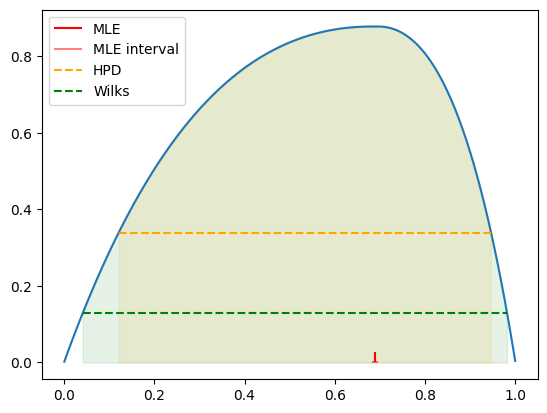

In [ ]:
x = inference.grid_result_by_size[size].grid
y = inference.grid_result_by_size[size].elr_on_grid
plt.plot(x, y)

mle = inference.mle_result_by_size[size].mle
mle_interval = inference.mle_result_by_size[size].interval
max_log_elr = inference.mle_result_by_size[size].max_log_elr
plt.vlines(
    mle, ymin=0, ymax=0.03*np.exp(max_log_elr), 
    colors='red', 
    label='MLE', 
)
plt.hlines(
    0, xmin=mle_interval[0], xmax=mle_interval[1], 
    colors='red', alpha=0.5, 
    label="MLE interval", 
)

hpd_interval = inference.hpd_result_by_size[size].hpd_95.interval
hpd_elr_cutoff = inference.hpd_result_by_size[size].hpd_95.elr_cutoff
plt.hlines(
    hpd_elr_cutoff, xmin=hpd_interval[0], xmax=hpd_interval[1], 
    color='orange', linestyles='--', 
    label='HPD', 
)
plt.fill_between(
    x, y, 
    where=(x >= hpd_interval[0]) & (x <= hpd_interval[1]), 
    color='orange', alpha=0.1, 
)

wilks_interval = inference.wilks_result_by_size[size].wilks_95.interval
wilks_elr_cutoff = inference.wilks_result_by_size[size].wilks_95.elr_cutoff
plt.hlines(
    wilks_elr_cutoff, xmin=wilks_interval[0], xmax=wilks_interval[1], 
    color='green', linestyles='--', 
    label='Wilks',
)
plt.fill_between(
    x, y, 
    where=(x >= wilks_interval[0]) & (x <= wilks_interval[1]), 
    color='green', alpha=0.1, 
)

plt.legend()
plt.show()